<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
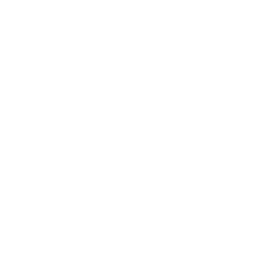
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Kliinisen lääketutkimuksen haittatapahtumien koodaus</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Lääketeollisuus / Lääketurvatoiminta &nbsp;|&nbsp; maaliskuu 2026</p>
</div>
</div>
</div>

## Yhteenveto

Haittatapahtuma-aineistot saapuvat sanatarkkoina MedDRA-suositeltuina
termeinä, mutta viranomaisten turvallisuustaulukot on jäsennelty
elinjärjestelmäluokan (SOC) mukaan. Tämä esimerkki rakentaa PROC FORMAT
-arvoformaatin, joka kartoittaa jokaisen suositellun termin sen
SOC-luokkaan, ja käyttää sitten tätä yhtä formaattia ohjaamaan kaikkia
jatkotaulukointeja: PROC FREQ -ristiintaulukoinnin SOC:sta hoitohaaran
mukaan, SOC:n jakautumisen vaikeusasteen mukaan sekä yhteenvedon
vakavista haittatapahtumista. Koska kartoitus asuu ainoastaan
formaatissa, tutkimuksen uudelleenkoodaus uuteen MedDRA-versioon on
yhden formaatin muokkaus eikä jokaisen raportin uudelleenkirjoitus.
ODS OUTPUT tallentaa SOC-frekvenssit datasetiksi jatkosignaalitarkastelua
varten.


## Tietolähteet

| Lähde | Kuvaus | Havainnot |
|--------|-------------|--------:|
| WORK.AE_RAW | Synteettiset haittatapahtumatietueet MedDRA-suositelluilla termeillä | 100 |
| WORK.RANDOMIZATION | Koehenkilöiden hoitohaaran kohdennukset | 100 |

Ympäristö toimii lisenssittömässä tilassa, joten jokainen luotu taulukko
on rajattu 100 havaintoon. Skenaario on mitoitettu tähän rajaan: 100
haittatapahtumaa poimitaan 12 termin MedDRA-paneelista, joka on
tyypillinen onkologian tutkimukselle.


---

In [1]:
/* --------------------------------------------------------
   Luo synteettinen haittatapahtuma-aineisto
   MedDRA-suositellut termit kartoitettu SOC-luokkiin
   -------------------------------------------------------- */
TIEDOT work.ae_raw;
    CALL streaminit(42);
    PITUUS aedecod $30 aesev $12;
    TAULUKKO pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    TEE i = 1 ASTI 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', KIRJOITA(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        JOS pt_idx = 1 NIIN aedecod = 'Pahoinvointi';
        MUUTEN JOS pt_idx = 2 NIIN aedecod = 'Päänsärky';
        MUUTEN JOS pt_idx = 3 NIIN aedecod = 'Oksentelu';
        MUUTEN JOS pt_idx = 4 NIIN aedecod = 'Ripuli';
        MUUTEN JOS pt_idx = 5 NIIN aedecod = 'Yskä';
        MUUTEN JOS pt_idx = 6 NIIN aedecod = 'Väsymys';
        MUUTEN JOS pt_idx = 7 NIIN aedecod = 'Nivelsärky';
        MUUTEN JOS pt_idx = 8 NIIN aedecod = 'Kuume';
        MUUTEN JOS pt_idx = 9 NIIN aedecod = 'Vatsakipu';
        MUUTEN JOS pt_idx = 10 NIIN aedecod = 'Neutropenia';
        MUUTEN JOS pt_idx = 11 NIIN aedecod = 'Kuumeinen neutropenia';
        MUUTEN aedecod = 'Infuusioon liittyvä reaktio';
        sev_idx = int(rand('uniform') * 3) + 1;
        JOS pt_idx SISÄLLÄ (10, 11) NIIN sev_idx = MAX(sev_idx, 2);
        JOS sev_idx = 1 NIIN aesev = 'LIEVÄ';
        MUUTEN JOS sev_idx = 2 NIIN aesev = 'KOHTALAINEN';
        MUUTEN aesev = 'VAIKEA';
        aeser = ifc(aesev = 'VAIKEA' AND rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        JOS aestdy > 365 NIIN aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', KIRJOITA(int(rand('uniform') * 25) + 1, z3.));
        TULOSTE;
    LOPPU;
    POISTA i pt_idx sev_idx;
SUORITA;



NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.76 seconds
  cpu   1.76 seconds


In [2]:
/* --------------------------------------------------------
   Luo koehenkilöiden satunnaistamistaulukko
   -------------------------------------------------------- */
TIEDOT work.randomization;
    CALL streaminit(43);
    PITUUS treatment_arm $20;
    TEE subject_id = 1 ASTI 800;
        usubjid = cat('ONC-2025-', KIRJOITA(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        JOS arm_idx = 1 NIIN treatment_arm = 'TUTKIMUSVALMISTE';
        MUUTEN JOS arm_idx = 2 NIIN treatment_arm = 'AKTIIVINEN_VERTAILU';
        MUUTEN treatment_arm = 'LUMELÄÄKE';
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        TULOSTE;
    LOPPU;
    POISTA arm_idx;
    MUOTO randomization_date date9.;
SUORITA;



NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                  Suositellun termin alustava frekvenssi (koodaamaton)                                  

                                                   The FREQ Procedure

Suositeltu termi                Frequency    Percent
-----------------------------------------------------
Päänsärky                              12     12.00
Ripuli                                 12     12.00
Kuume                                  11     11.00
Väsymys                                11     11.00
Nivelsärky                             10     10.00
Pahoinvointi                           10     10.00
Infuusioon liittyvä reaktio             8      8.00
Yskä                                    7      7.00
Kuumeinen neutropenia                   5      5.00
Neutropenia                             5      5.00
Vatsakipu                               5      5.00
Oksentelu                               4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


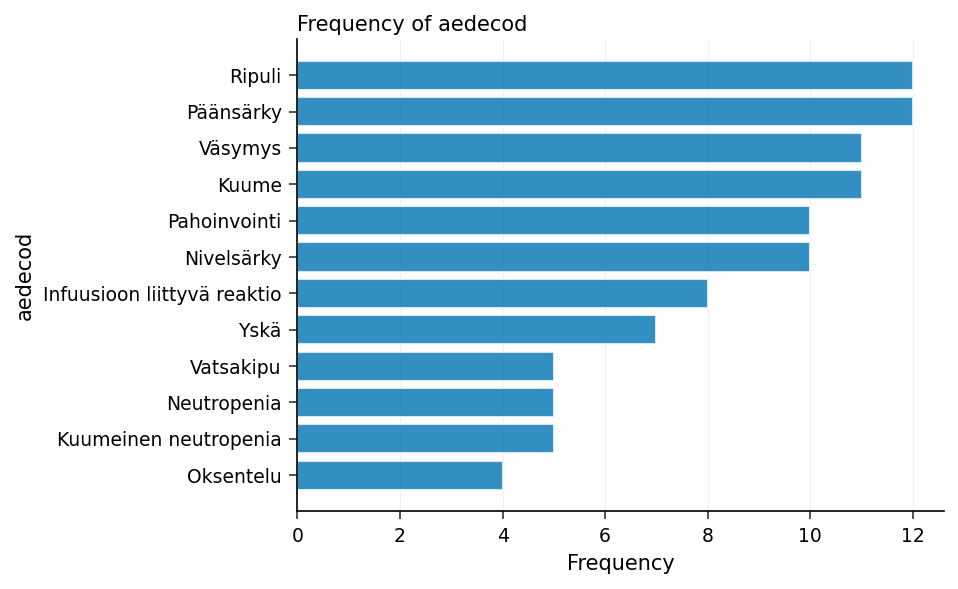

In [3]:
/* --------------------------------------------------------
   Suositellun termin alustava frekvenssi ennen SOC-kartoitusta
   -------------------------------------------------------- */
PROSEDUURI FREKVENSSIT TIEDOT=work.ae_raw ORDER=FREKVENSSIT;
    TABLES aedecod / nocum;
    NIMIKE aedecod='Suositeltu termi';
    OTSIKKO 'Suositellun termin alustava frekvenssi (koodaamaton)';
SUORITA;


---

                                  Suositellun termin alustava frekvenssi (koodaamaton)                                  




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


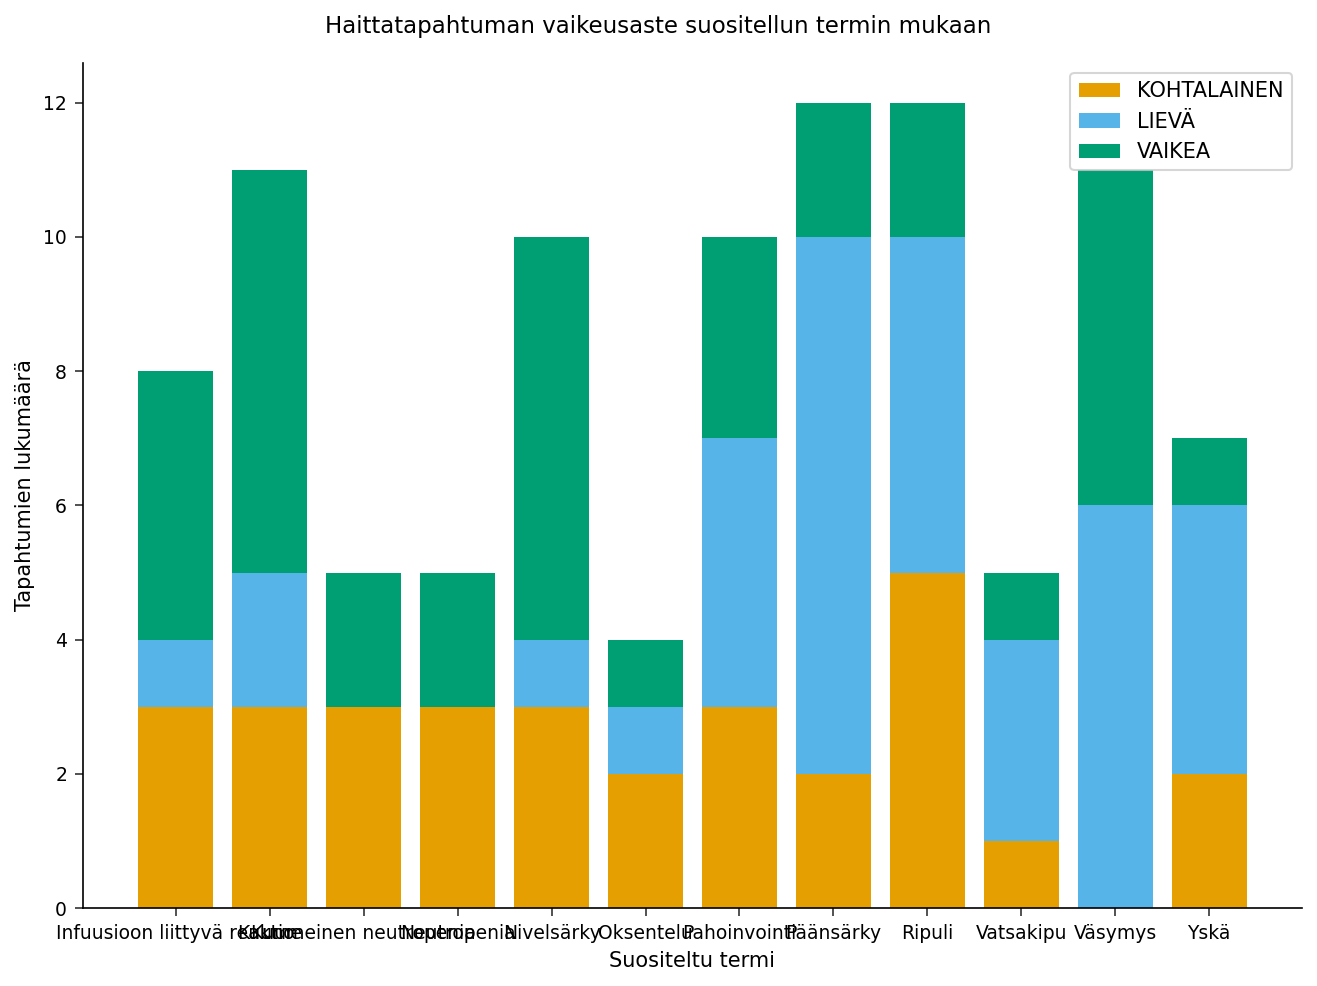

In [4]:
/* --------------------------------------------------------
   Haittatapahtuman vaikeusastejakauma suositellun termin mukaan
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS NIMIKE='Suositeltu termi' fitpolicy=ROTATE;
    YAXIS NIMIKE='Tapahtumien lukumäärä';
    OTSIKKO 'Haittatapahtuman vaikeusaste suositellun termin mukaan';
SUORITA;


---

In [5]:
/* --------------------------------------------------------
   Määritä MedDRA-suositellun termin -> elinjärjestelmäluokan
   arvoformaatti. Formaatin avaimena on suositellun termin
   teksti, joten yksi PUT()-kutsu koodaa minkä tahansa
   haittatapahtumatietueen sen SOC-luokkaan.
   -------------------------------------------------------- */
PROSEDUURI MUOTO;
    VALUE $pt_to_soc
        'Pahoinvointi'                 = 'Ruoansulatuselimistön häiriöt'
        'Oksentelu'                    = 'Ruoansulatuselimistön häiriöt'
        'Ripuli'                       = 'Ruoansulatuselimistön häiriöt'
        'Vatsakipu'                    = 'Ruoansulatuselimistön häiriöt'
        'Päänsärky'                    = 'Hermoston häiriöt'
        'Väsymys'                      = 'Yleishäiriöt'
        'Kuume'                        = 'Yleishäiriöt'
        'Yskä'                         = 'Hengityselinten häiriöt'
        'Nivelsärky'                   = 'Tuki- ja liikuntaelimistön häiriöt'
        'Neutropenia'                  = 'Veren ja imukudoksen häiriöt'
        'Kuumeinen neutropenia'        = 'Veren ja imukudoksen häiriöt'
        'Infuusioon liittyvä reaktio'  = 'Immuunijärjestelmän häiriöt'
        OTHER                          = 'Koodaamaton'
    ;
    VALUE $sev_rank
        'LIEVÄ'       = '1-Lievä'
        'KOHTALAINEN' = '2-Kohtalainen'
        'VAIKEA'      = '3-Vaikea'
        OTHER         = '9-Tuntematon'
    ;
    VALUE $serious_fmt
        'Y' = 'Vakava'
        'N' = 'Ei-vakava'
    ;
SUORITA;



NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Yhdistä haittatapahtumatietueet hoitohaaraan ja käytä
   sitten SOC-formaattia. PUT(aedecod, $pt_to_soc.) on ainoa
   tarvittava kartoitusvaihe; vaikeusaste ja vakavuus koodataan
   samalla tavalla.
   -------------------------------------------------------- */
PROSEDUURI LAJITTELE TIEDOT=work.ae_raw; MUKAAN usubjid; SUORITA;
PROSEDUURI LAJITTELE TIEDOT=work.randomization; MUKAAN usubjid; SUORITA;

TIEDOT work.ae_coded;
    PITUUS soc_class $40 severity_rank $15 serious_flag $12;
    YHDISTÄ work.ae_raw (SISÄLLÄ=a)
          work.randomization (SISÄLLÄ=b SÄILYTÄ=usubjid treatment_arm);
    MUKAAN usubjid;
    JOS a;
    soc_class     = KIRJOITA(aedecod, $pt_to_soc.);
    severity_rank = KIRJOITA(aesev,   $sev_rank.);
    serious_flag  = KIRJOITA(aeser,   $serious_fmt.);
SUORITA;



NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


                       Haittatapahtumien esiintyvyys elinjärjestelmäluokan ja hoitohaaran mukaan                        

                                                   The FREQ Procedure

Table of Elinjärjestelmäluokka by Hoitohaara

Elinjärjestelmäluokka            |AKTIIVINEN_VERTAILU |          LUMELÄÄKE |   TUTKIMUSVALMISTE |               Total
---------------------------------+--------------------+--------------------+--------------------+--------------------
Immuunijärjestelmän häiriöt      |                  0 |                  1 |                  1 |                   2
---------------------------------+--------------------+--------------------+--------------------+--------------------
Ruoansulatuselimistön häiriöt    |                  1 |                  2 |                  0 |                   3
---------------------------------+--------------------+--------------------+--------------------+--------------------
Veren ja imukudoksen häiriöt     |                  0


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


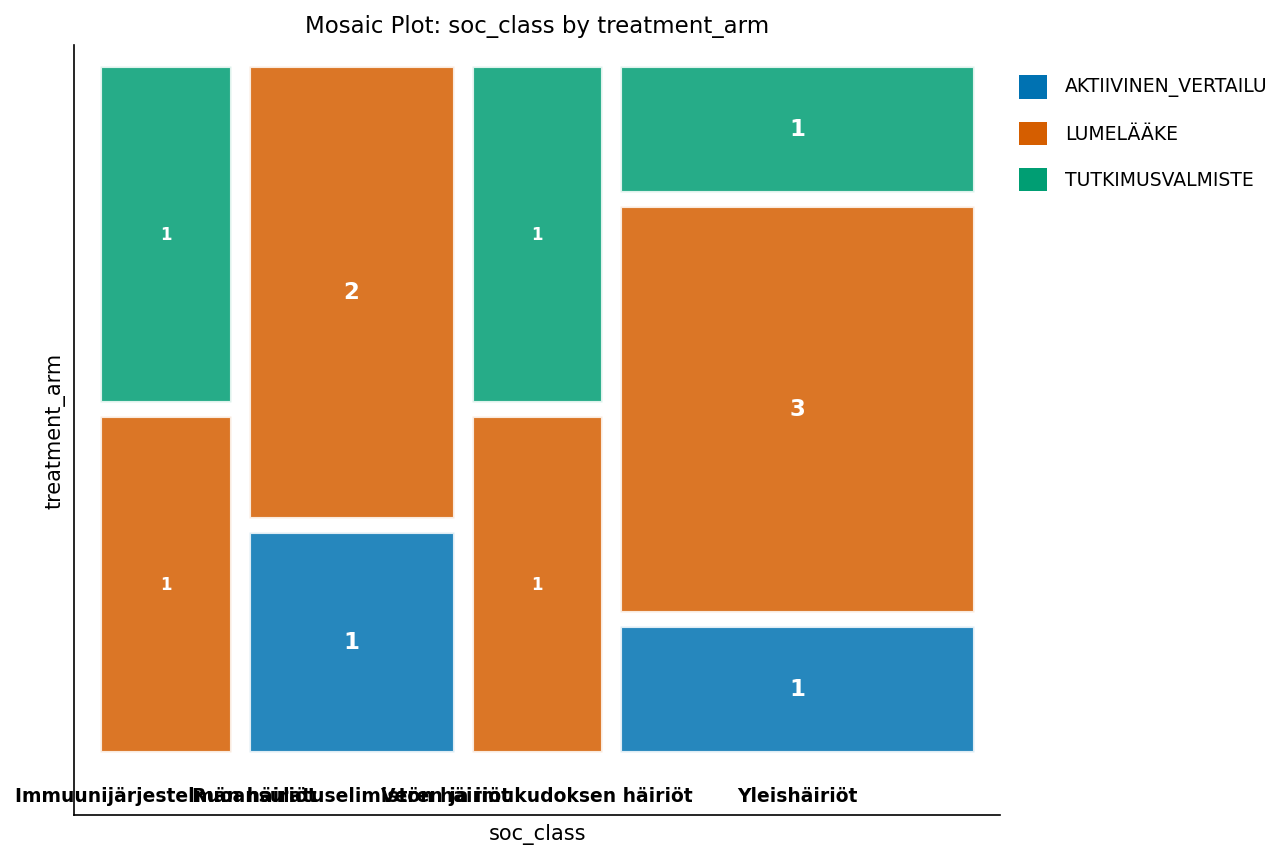

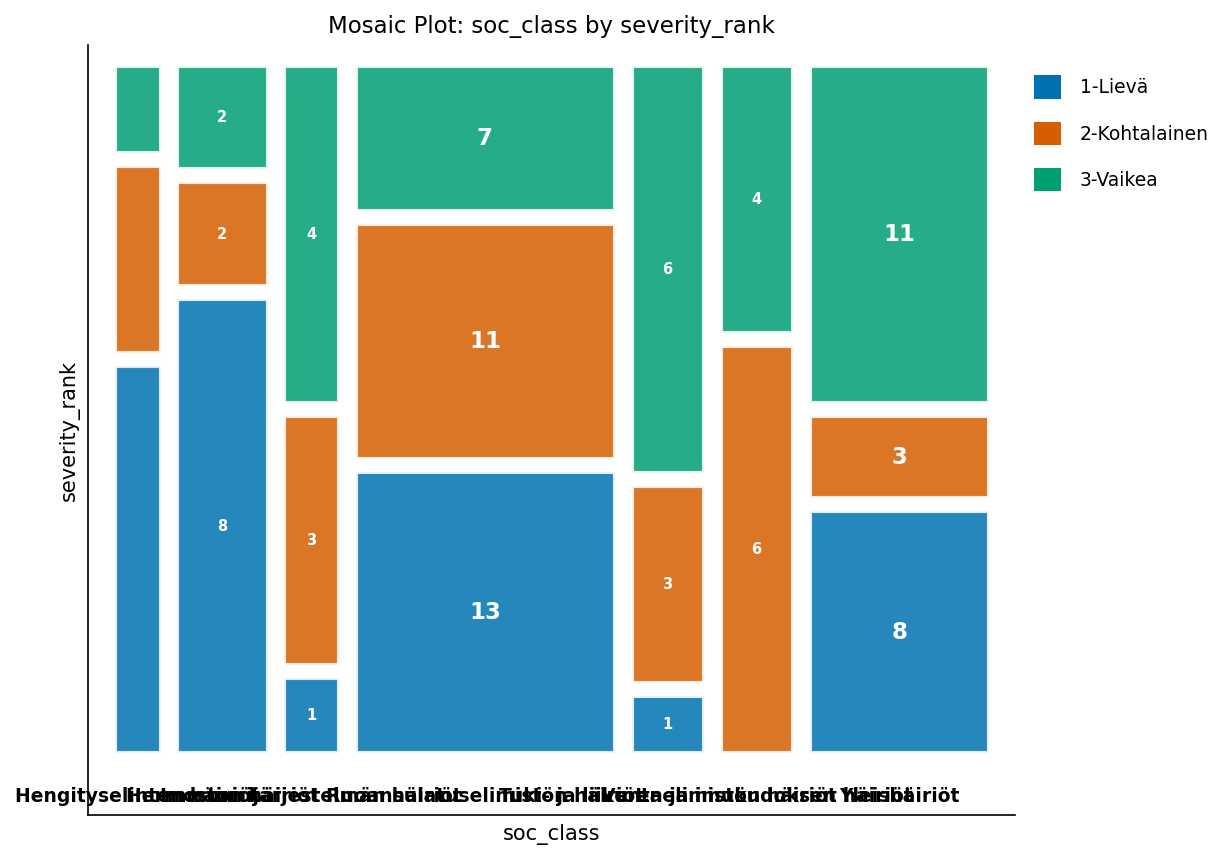

In [7]:
/* --------------------------------------------------------
   SOC-tason frekvenssi hoitohaaran mukaan
   ODS OUTPUT tallentaa tulokset signaalitarkastelua varten
   -------------------------------------------------------- */
ODS TULOSTE onewayfreqs=work.soc_freq_table;

PROSEDUURI FREKVENSSIT TIEDOT=work.ae_coded ORDER=FREKVENSSIT;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    NIMIKE soc_class='Elinjärjestelmäluokka' treatment_arm='Hoitohaara' severity_rank='Vaikeusasteluokka';
    OTSIKKO 'Haittatapahtumien esiintyvyys elinjärjestelmäluokan ja hoitohaaran mukaan';
SUORITA;

ODS TULOSTE CLOSE;


                          Vakavat haittatapahtumat elinjärjestelmäluokan ja hoitohaaran mukaan                          

                                                   The FREQ Procedure

Table of Elinjärjestelmäluokka by Hoitohaara

Elinjärjestelmäluokka           |AKTIIVINEN_VERTAILU |          LUMELÄÄKE |   TUTKIMUSVALMISTE |               Total
--------------------------------+--------------------+--------------------+--------------------+--------------------
Immuunijärjestelmän häiriöt     |                  0 |                  1 |                  0 |                   1
--------------------------------+--------------------+--------------------+--------------------+--------------------
Yleishäiriöt                    |                  1 |                  1 |                  1 |                   3
--------------------------------+--------------------+--------------------+--------------------+--------------------
Total                           |                  1 |     


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


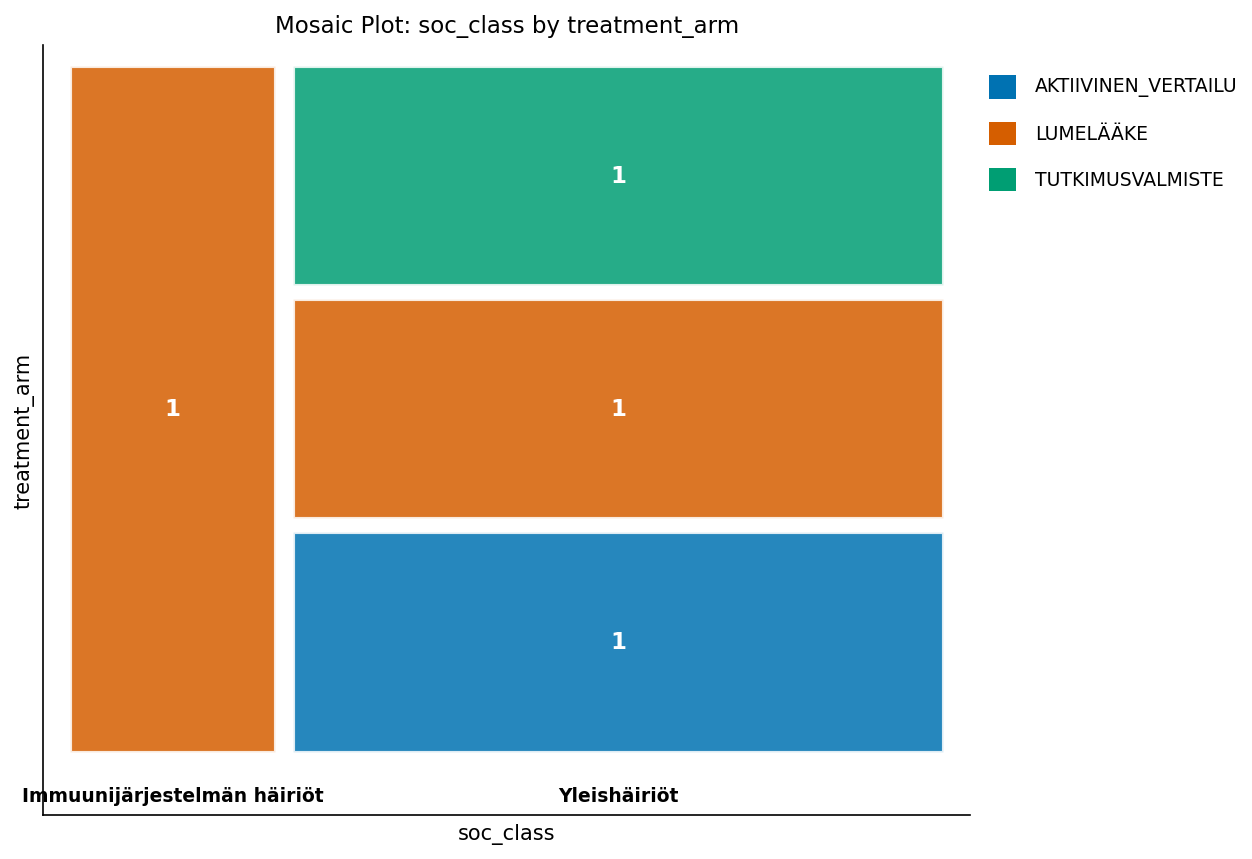

In [8]:
/* --------------------------------------------------------
   Vakavien haittatapahtumien yhteenveto SOC:n mukaan
   turvallisuuskertomusta varten
   -------------------------------------------------------- */
PROSEDUURI FREKVENSSIT TIEDOT=work.ae_coded;
    MISSÄ aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    NIMIKE soc_class='Elinjärjestelmäluokka' treatment_arm='Hoitohaara';
    OTSIKKO 'Vakavat haittatapahtumat elinjärjestelmäluokan ja hoitohaaran mukaan';
SUORITA;


---

### Tulkinta

Yksi ainoa `$pt_to_soc`-arvoformaatti koodasi kaikki 100 haittatapahtumaa
12 sanatarkasta MedDRA-suositellusta termistä 7 elinjärjestelmäluokkaan,
ja tämä yksi formaatti ohjasi jokaista alla olevaa taulukkoa ilman datan
uudelleenkoodausta.

SOC-luokan ja vaikeusasteen mukaan **Ruoansulatuselimistön häiriöt** on
yleisin luokka 31 tapahtumalla sadasta (13 lievää, 11 kohtalaista, 7
vaikeaa), ja seuraavaksi yleisin on **Yleishäiriöt** 22 tapahtumalla.
Muut luokat ovat pienempiä: Hermoston häiriöt (12), Veren ja imukudoksen
häiriöt (10), Tuki- ja liikuntaelimistön häiriöt (10), Immuunijärjestelmän
häiriöt (8) ja Hengityselinten häiriöt (7). Kaikkien tapahtumien kesken
vaikeusastejakauma on 35 lievää, 30 kohtalaista ja 35 vaikeaa.

Vain 4 tapahtumaa merkittiin vakaviksi (`aeser='Y'`): 3 Yleishäiriöt
-luokassa (yksi kutakin hoitohaaraa kohden) ja 1 Immuunijärjestelmän
häiriöt -luokassa (lumelääke). SOC:n ja hoitohaaran ristiintaulukointi
perustuu 12 tapahtumaan, joiden koehenkilö täsmäsi
satunnaistamistietueeseen, joten haarakohtaiset lukumäärät ovat
havainnollisia eivätkä tilastollisesti voimakkaita haarojen väliseen
vertailuun.

Keskeinen opetus on FORMAT-mekanismi, ei synteettiset luvut: koska
suositellun termin ja SOC:n välinen kartoitus asuu kokonaan PROC
FORMATissa, sama `PUT(aedecod, $pt_to_soc.)`-kutsu koodaa koko aineiston
uudelleen, ja päivitys uuteen MedDRA-sanastoversioon tarkoittaa yhden
formaatin muokkausta jokaisen raportin sijaan. ODS OUTPUT tallensi
SOC-frekvenssit muuttujaksi `work.soc_freq_table` jatkosignaalitarkastelua
varten.


---

In [9]:
/* --------------------------------------------------------
   Vie SOC-koodattu haittatapahtuma-aineisto
   turvallisuussignaalitarkastelua varten. Yksi $pt_to_soc
   -formaatti on täyttänyt soc_class-muuttujan, joten viety
   tiedosto on valmis jatkoanalyysiin SOC-tasolla.
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
SUORITA;



NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>-alustalla
</div>
</div>